In [3]:
import os
import sys
project_root = os.path.abspath(os.path.join(os.getcwd(), '../..'))
sys.path.append(project_root)

# Dataset generation

Main idea: 
- Crear un dataset de propiedades dentro de distritos de lima.
- 3 propiedades por distrito
- Crear un prompt para cada propiedad. 
- Este prompt se traduce en una clase pydantic.
- La clase pydantic se traduce en un QUERY de OpenSearch
- El query de OpenSearch se traduce en un resultado. 
- Se usará metrica recall@k

## Coordinates based generation using pandas

In [1]:
import geopandas as gpd
import pandas as pd
from pathlib import Path

In [2]:
shp_path = Path.cwd().parent.parent / "data-gen" / "data" / "Distrital INEI 2023 geogpsperu SuyoPomalia" / "Distrital INEI 2023 geogpsperu SuyoPomalia.shp"
peru = gpd.read_file(shp_path)

In [3]:
callao = peru[peru["DEPARTAMEN"] == "CALLAO"]

In [4]:
lima_metropolitana = peru[(peru["DEPARTAMEN"] == "LIMA") & (peru["PROVINCIA"] == "LIMA")]

In [5]:
distritos = pd.concat([callao, lima_metropolitana])

In [6]:
print(len(callao))
print(len(lima_metropolitana))
print(len(distritos))

7
43
50


In [7]:
distritos

,UBIGEO,CCDD,CCPP,CCDI,DEPARTAMEN,PROVINCIA,DISTRITO,OBJECTID,ESRI_OID,geometry
695,070101,07,01,01,CALLAO,CALLAO,CALLAO,696.0,696.0,"POLYGON ((-77.12995 -11.93682, -77.1299 -11.93..."
696,070102,07,01,02,CALLAO,CALLAO,BELLAVISTA,697.0,697.0,"POLYGON ((-77.08767 -12.05191, -77.08768 -12.0..."
697,070103,07,01,03,CALLAO,CALLAO,CARMEN DE LA LEGUA REYNOSO,698.0,698.0,"POLYGON ((-77.08303 -12.03634, -77.08297 -12.0..."
698,070104,07,01,04,CALLAO,CALLAO,LA PERLA,699.0,699.0,"POLYGON ((-77.10465 -12.06328, -77.1046 -12.06..."
699,070105,07,01,05,CALLAO,CALLAO,LA PUNTA,700.0,700.0,"POLYGON ((-77.15878 -12.06647, -77.15875 -12.0..."
700,070106,07,01,06,CALLAO,CALLAO,VENTANILLA,701.0,701.0,"POLYGON ((-77.13522 -11.81819, -77.13504 -11.8..."
701,070107,07,01,07,CALLAO,CALLAO,MI PERU,702.0,702.0,"POLYGON ((-77.1145 -11.84227, -77.11435 -11.84..."
1293,150101,15,01,01,LIMA,LIMA,LIMA,1294.0,1294.0,"POLYGON ((-77.00972 -12.03083, -77.00921 -12.0..."
1294,150102,15,01,02,LIMA,LIMA,ANCON,1295.0,1295.0,"POLYGON ((-77.06652 -11.57251, -77.06614 -11.5..."
1295,150103,15,01,03,LIMA,LIMA,ATE,1296.0,1296.0,"POLYGON ((-76.83689 -11.9937, -76.83517 -11.99..."


## Generating Random Points

In [8]:
from shapely.geometry import Point
import random

def random_points_in_polygon(geom , n_points, seed=None):
    rng = random.Random(seed)
    minx, miny, maxx, maxy = geom.bounds
    pts = []
    while len(pts) < n_points:
        p = Point(rng.uniform(minx, maxx), rng.uniform(miny, maxy))
        if geom.contains(p):
            pts.append(p)
    return pts

In [9]:
# Generamos puntos aleatorios
distritos["random_points"] = distritos.geometry.apply(
    random_points_in_polygon, n_points=3, seed=42)

In [10]:
# i.e.
distritos["random_points"].iloc[0]

[<POINT (-77.136 -12.041)>,
 <POINT (-77.131 -12.05)>,
 <POINT (-77.128 -11.997)>]

In [33]:
puntos_por_distrito = distritos.explode("random_points")
puntos_por_distrito = puntos_por_distrito[["DEPARTAMEN", "PROVINCIA", "DISTRITO", "geometry", "random_points"]]
puntos_por_distrito.rename(columns={
    "DEPARTAMEN": "departamento",
    "PROVINCIA": "provincia",
    "DISTRITO": "distrito"
}, inplace=True)
puntos_por_distrito

,departamento,provincia,distrito,geometry,random_points
695,CALLAO,CALLAO,CALLAO,"POLYGON ((-77.12995 -11.93682, -77.1299 -11.93...",POINT (-77.13630741549312 -12.040654106070631)
695,CALLAO,CALLAO,CALLAO,"POLYGON ((-77.12995 -11.93682, -77.1299 -11.93...",POINT (-77.13103763692733 -12.049708281600813)
695,CALLAO,CALLAO,CALLAO,"POLYGON ((-77.12995 -11.93682, -77.1299 -11.93...",POINT (-77.12794435630373 -11.996696788221161)
696,CALLAO,CALLAO,BELLAVISTA,"POLYGON ((-77.08767 -12.05191, -77.08768 -12.0...",POINT (-77.12130089077424 -12.064253660434632)
696,CALLAO,CALLAO,BELLAVISTA,"POLYGON ((-77.08767 -12.05191, -77.08768 -12.0...",POINT (-77.09953777328617 -12.056942545202597)
...,...,...,...,...,...
1334,LIMA,LIMA,VILLA EL SALVADOR,"POLYGON ((-76.94163 -12.18351, -76.9416 -12.18...",POINT (-76.91698342923416 -12.246595590030488)
1334,LIMA,LIMA,VILLA EL SALVADOR,"POLYGON ((-76.94163 -12.18351, -76.9416 -12.18...",POINT (-76.96231093023829 -12.21726094456295)
1335,LIMA,LIMA,VILLA MARIA DEL TRIUNFO,"POLYGON ((-76.91742 -12.11903, -76.91621 -12.1...",POINT (-76.91021139682324 -12.231592093843561)
1335,LIMA,LIMA,VILLA MARIA DEL TRIUNFO,"POLYGON ((-76.91742 -12.11903, -76.91621 -12.1...",POINT (-76.90236981209297 -12.156282467566026)


In [12]:
# Verificando integridad de puntos
sum(puntos_por_distrito.apply(lambda x: x["geometry"].contains(x["random_points"]), axis=1))

150

## Generación de Dataset para carga en PostgreSQL

In [83]:
import psycopg
from app.core.config import POSTGRE_DB_USER, POSTGRE_DB_PASSWORD, POSTGRE_DB_URL, POSTGRESQL_PORT, POSTGRESQL_DEV_DB

In [84]:
connection_string = f'postgresql://{POSTGRE_DB_USER}:{POSTGRE_DB_PASSWORD}@{POSTGRE_DB_URL}:{POSTGRESQL_PORT}/{POSTGRESQL_DEV_DB}'

In [ ]:
## Getting table schema
conn = psycopg.connect(
    conninfo=connection_string
)

with conn.cursor() as cur:
    cur.execute("""
        SELECT column_name, data_type
        FROM information_schema.columns
        WHERE table_schema = 'public' AND table_name = 'properties'
        ORDER BY ordinal_position;
""")
    
    for row in cur.fetchall():
        print(row)

conn.close()

('id', 'uuid')
('title', 'character varying')
('description', 'text')
('property_type', 'character varying')
('operation_type', 'character varying')
('location', 'character varying')
('address', 'character varying')
('price', 'numeric')
('status', 'character varying')
('user_id', 'uuid')
('created_at', 'timestamp without time zone')
('updated_at', 'timestamp without time zone')
('photos', 'text')
('geolocation', 'ARRAY')


In [62]:
columns = [
            'id',
            'title', 
            'description', 
            'property_type', 
            'operation_type', 
            'location',
            'address',
            'price',
            'status',
            'user_id',
            'geolocation'
           ]

In [18]:
from uuid import uuid4

In [74]:
properties_df = puntos_por_distrito.copy()
properties_df['location_query'] = properties_df["provincia"] + ", " + properties_df['distrito'] # Useful for later query
properties_df['id'] = [uuid4() for i in range(len(properties_df)) ]
properties_df['title'] = '-'
properties_df['description'] = '-'
properties_df['property_type'] = 'departamento'
properties_df['operation_type'] = 'alquiler'
properties_df['location'] = 'Perú'
properties_df['address'] = '-'
properties_df['price'] = [ random.randint(1000, 3000) for i in range(len(properties_df)) ]
properties_df['status'] = 'test'
properties_df["user_id"] = "c32774fd-ca8d-4bb2-9273-029a1e7a9d8e"
properties_df["geolocation"] = properties_df.apply(lambda row: [row['random_points'].y,  row['random_points'].x], axis=1)

In [75]:
properties_df[columns]

,id,title,description,property_type,operation_type,location,address,price,status,user_id,geolocation
695,a7a539ea-6f4b-46ed-ab56-d398a190658c,-,-,departamento,alquiler,Perú,-,2804,test,c32774fd-ca8d-4bb2-9273-029a1e7a9d8e,"[-12.040654106070631, -77.13630741549312]"
695,7074f888-0267-443b-a277-e975e931a685,-,-,departamento,alquiler,Perú,-,1474,test,c32774fd-ca8d-4bb2-9273-029a1e7a9d8e,"[-12.049708281600813, -77.13103763692733]"
695,144acd5d-1863-4f4d-9967-876d727ba335,-,-,departamento,alquiler,Perú,-,1387,test,c32774fd-ca8d-4bb2-9273-029a1e7a9d8e,"[-11.996696788221161, -77.12794435630373]"
696,99b9c286-92a1-4fad-b656-e5b9cbb24817,-,-,departamento,alquiler,Perú,-,2833,test,c32774fd-ca8d-4bb2-9273-029a1e7a9d8e,"[-12.064253660434632, -77.12130089077424]"
696,51f1d69a-d15f-4d36-83c9-ea1a25ca2eff,-,-,departamento,alquiler,Perú,-,1133,test,c32774fd-ca8d-4bb2-9273-029a1e7a9d8e,"[-12.056942545202597, -77.09953777328617]"
...,...,...,...,...,...,...,...,...,...,...,...
1334,dbe176df-5487-4b28-b67e-b424937bd597,-,-,departamento,alquiler,Perú,-,2866,test,c32774fd-ca8d-4bb2-9273-029a1e7a9d8e,"[-12.246595590030488, -76.91698342923416]"
1334,20c06b90-3ef8-4094-bc3e-f0a33cd91f14,-,-,departamento,alquiler,Perú,-,1301,test,c32774fd-ca8d-4bb2-9273-029a1e7a9d8e,"[-12.21726094456295, -76.96231093023829]"
1335,b0d43ebf-17ef-4eff-8b3e-c870be340ddf,-,-,departamento,alquiler,Perú,-,2205,test,c32774fd-ca8d-4bb2-9273-029a1e7a9d8e,"[-12.231592093843561, -76.91021139682324]"
1335,49cd80e6-8f4e-4236-b06c-0bb044186c0a,-,-,departamento,alquiler,Perú,-,2617,test,c32774fd-ca8d-4bb2-9273-029a1e7a9d8e,"[-12.156282467566026, -76.90236981209297]"


In [ ]:
properties_df.to_file('generated_data/properties.gpkg', driver='GPKG') # GPKG driver for column name length > 10

## Carga en PostgreSQL

In [20]:
import geopandas as gpd

In [ ]:
properties_df = gpd.read_file('generated_data/properties.gpkg')

,departamento,provincia,distrito,random_points,location_query,id,title,description,property_type,operation_type,location,address,price,status,user_id,geolocation,geometry
0,CALLAO,CALLAO,CALLAO,POINT (-77.13630741549312 -12.040654106070631),"CALLAO, CALLAO",a7a539ea-6f4b-46ed-ab56-d398a190658c,-,-,departamento,alquiler,Perú,-,2804,test,c32774fd-ca8d-4bb2-9273-029a1e7a9d8e,"[-12.040654106070631, -77.13630741549312]","MULTIPOLYGON (((-77.12995 -11.93682, -77.1299 ..."
1,CALLAO,CALLAO,CALLAO,POINT (-77.13103763692733 -12.049708281600813),"CALLAO, CALLAO",7074f888-0267-443b-a277-e975e931a685,-,-,departamento,alquiler,Perú,-,1474,test,c32774fd-ca8d-4bb2-9273-029a1e7a9d8e,"[-12.049708281600813, -77.13103763692733]","MULTIPOLYGON (((-77.12995 -11.93682, -77.1299 ..."
2,CALLAO,CALLAO,CALLAO,POINT (-77.12794435630373 -11.996696788221161),"CALLAO, CALLAO",144acd5d-1863-4f4d-9967-876d727ba335,-,-,departamento,alquiler,Perú,-,1387,test,c32774fd-ca8d-4bb2-9273-029a1e7a9d8e,"[-11.996696788221161, -77.12794435630373]","MULTIPOLYGON (((-77.12995 -11.93682, -77.1299 ..."
3,CALLAO,CALLAO,BELLAVISTA,POINT (-77.12130089077424 -12.064253660434632),"CALLAO, BELLAVISTA",99b9c286-92a1-4fad-b656-e5b9cbb24817,-,-,departamento,alquiler,Perú,-,2833,test,c32774fd-ca8d-4bb2-9273-029a1e7a9d8e,"[-12.064253660434632, -77.12130089077424]","MULTIPOLYGON (((-77.08767 -12.05191, -77.08768..."
4,CALLAO,CALLAO,BELLAVISTA,POINT (-77.09953777328617 -12.056942545202597),"CALLAO, BELLAVISTA",51f1d69a-d15f-4d36-83c9-ea1a25ca2eff,-,-,departamento,alquiler,Perú,-,1133,test,c32774fd-ca8d-4bb2-9273-029a1e7a9d8e,"[-12.056942545202597, -77.09953777328617]","MULTIPOLYGON (((-77.08767 -12.05191, -77.08768..."


In [92]:
import ast

properties_df["geolocation"] = properties_df["geolocation"].apply(ast.literal_eval)

In [ ]:
import psycopg
from psycopg2.extras import execute_batch

conn = psycopg.connect(connection_string)
records = properties_df.to_dict("records")

with conn.cursor() as cur:
    sql = f"""
        INSERT INTO public.properties ({", ".join(columns)})
        VALUES ({", ".join(["%s"] * len(columns))})
        ON CONFLICT (id) DO NOTHING;
    """
    values = [tuple(row[col] for col in columns) for row in records]
    cur.executemany(sql, values)
    #execute_batch(cur, sql, values, page_size=500)

conn.commit()
conn.close()

: 

# Diseño de prueba

Recordemos que para cada distrito hay 3 departamentos, o 3 ids. 
Lo que queremos es probar que al buscar en un distrito nos devuelva los 3 ids requeridos con la fórmula actual.
Verificar que distritos fallan más.

Proceso:
1. Crear data con query (objeto de pydantic) vs IDs (3 ids)
3. Realizar consulta para cada query con nuestro search engine y capturar las propiedades obtenidas.
4. Medir recall@k

## Dataset

In [121]:
columns = ['location_query', 'id', 'geolocation', 'geometry']

In [129]:
query_dataset = properties_df[columns]
query_dataset.head()

,location_query,id,geolocation,geometry
0,"CALLAO, CALLAO",a7a539ea-6f4b-46ed-ab56-d398a190658c,"[-12.040654106070631, -77.13630741549312]","MULTIPOLYGON (((-77.12995 -11.93682, -77.1299 ..."
1,"CALLAO, CALLAO",7074f888-0267-443b-a277-e975e931a685,"[-12.049708281600813, -77.13103763692733]","MULTIPOLYGON (((-77.12995 -11.93682, -77.1299 ..."
2,"CALLAO, CALLAO",144acd5d-1863-4f4d-9967-876d727ba335,"[-11.996696788221161, -77.12794435630373]","MULTIPOLYGON (((-77.12995 -11.93682, -77.1299 ..."
3,"CALLAO, BELLAVISTA",99b9c286-92a1-4fad-b656-e5b9cbb24817,"[-12.064253660434632, -77.12130089077424]","MULTIPOLYGON (((-77.08767 -12.05191, -77.08768..."
4,"CALLAO, BELLAVISTA",51f1d69a-d15f-4d36-83c9-ea1a25ca2eff,"[-12.056942545202597, -77.09953777328617]","MULTIPOLYGON (((-77.08767 -12.05191, -77.08768..."


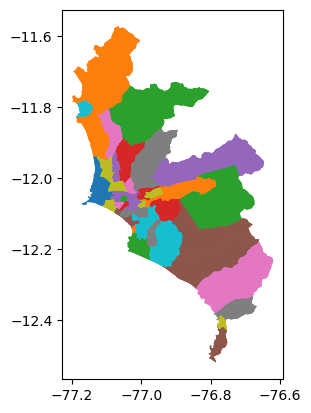

In [123]:
import matplotlib.pyplot as plt

ax = query_dataset.plot(column='location_query')
plt.show()

In [126]:
groupby_cols = ['location_query',  'geometry']

In [130]:
grouped_query_dataset = query_dataset.groupby(groupby_cols, as_index=False).agg({'id': lambda rows: [row for row in rows],
                                                                                 'geolocation': lambda rows: [row for row in rows]})

In [132]:
grouped_query_dataset = gpd.GeoDataFrame(grouped_query_dataset, geometry="geometry", crs="EPSG:4326")
grouped_query_dataset.head()

,location_query,geometry,id,geolocation
0,"CALLAO, BELLAVISTA","MULTIPOLYGON (((-77.08767 -12.05191, -77.08768...","[99b9c286-92a1-4fad-b656-e5b9cbb24817, 51f1d69...","[[-12.064253660434632, -77.12130089077424], [-..."
1,"CALLAO, CALLAO","MULTIPOLYGON (((-77.12995 -11.93682, -77.1299 ...","[a7a539ea-6f4b-46ed-ab56-d398a190658c, 7074f88...","[[-12.040654106070631, -77.13630741549312], [-..."
2,"CALLAO, CARMEN DE LA LEGUA REYNOSO","MULTIPOLYGON (((-77.08303 -12.03634, -77.08297...","[f43a38a4-42e4-4de5-8cfb-df3ec89e900b, 5f757a4...","[[-12.045712844139185, -77.09439749593251], [-..."
3,"CALLAO, LA PERLA","MULTIPOLYGON (((-77.10465 -12.06328, -77.1046 ...","[274f2d67-f82b-409c-a410-4682256367d0, 8674647...","[[-12.068516141111967, -77.11166683431348], [-..."
4,"CALLAO, LA PUNTA","MULTIPOLYGON (((-77.15878 -12.06647, -77.15875...","[f027c7e2-39bb-46ee-b6ef-6e6b57959cc3, 6a0ce28...","[[-12.073358076377465, -77.16692584023498], [-..."


In [133]:
grouped_query_dataset.to_file('generated_data/grouped_properties.gpkg', driver='GPKG')

### Adding Query Object 

In [9]:
from app.models.PropertyLead import PropertySearchParams
from app.services.geolocation.location_verifier import verify_location

In [6]:
lead = PropertySearchParams(location={'value': 'CALLAO, BELLAVISTA'})
lead.test_query()
# Observaciones:
# status debe ser : 'test'
# geo_distance / geolocation no tiene lat lon

{'size': 3,
 'query': {'bool': {'must': [{'term': {'status': 'test'}}],
   'filter': [{'geo_distance': {'distance': '5km',
      'geolocation': {'lat': None, 'lon': None}}}],
   'should': [{'function_score': {'query': {'match_all': {}},
      'functions': [{'gauss': {'geolocation': {'origin': {'lat': None,
           'lon': None},
          'scale': '2km',
          'offset': '0km',
          'decay': 0.5}},
        'weight': 2.0}],
      'score_mode': 'sum'}}],
   'minimum_should_match': 1}}}

In [15]:
search_location = lead.location.value
_, coordinates = verify_location(search_location.lower())
lead.location.lat = coordinates.get("lat")
lead.location.lon = coordinates.get("lon")
_, coordinates

resultado obtenido con opencage


('Bellavista, Callao, Perú', {'lat': -12.0597362, 'lon': -77.1111612})

In [41]:
# Creamos una función para generar una celda con el query deseado
def generate_query_cell(location):
    lead = PropertySearchParams(location={'value': location})
    _, coordinates = verify_location(lead.location.value.lower())
    lead.location.lat = coordinates.get("lat")
    lead.location.lon = coordinates.get("lon")
    return lead.test_query()


In [42]:
grouped_query_dataset["lead"] = grouped_query_dataset.apply(lambda row: generate_query_cell(row['location_query']),axis=1)

resultado obtenido con opencage
resultado obtenido con opencage
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con opencage
resultado obtenido con opencage
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
resultado obtenido con fuzzy
re

In [43]:
grouped_query_dataset

,location_query,property_type,operation_type,location,status,id,lead
0,"CALLAO, BELLAVISTA",departamento,alquiler,Perú,test,"[99b9c286-92a1-4fad-b656-e5b9cbb24817, 51f1d69...","{'size': 3, 'query': {'bool': {'must': [{'term..."
1,"CALLAO, CALLAO",departamento,alquiler,Perú,test,"[a7a539ea-6f4b-46ed-ab56-d398a190658c, 7074f88...","{'size': 3, 'query': {'bool': {'must': [{'term..."
2,"CALLAO, CARMEN DE LA LEGUA REYNOSO",departamento,alquiler,Perú,test,"[f43a38a4-42e4-4de5-8cfb-df3ec89e900b, 5f757a4...","{'size': 3, 'query': {'bool': {'must': [{'term..."
3,"CALLAO, LA PERLA",departamento,alquiler,Perú,test,"[274f2d67-f82b-409c-a410-4682256367d0, 8674647...","{'size': 3, 'query': {'bool': {'must': [{'term..."
4,"CALLAO, LA PUNTA",departamento,alquiler,Perú,test,"[f027c7e2-39bb-46ee-b6ef-6e6b57959cc3, 6a0ce28...","{'size': 3, 'query': {'bool': {'must': [{'term..."
5,"CALLAO, MI PERU",departamento,alquiler,Perú,test,"[71a0df6c-7b27-47cd-94eb-63e90e8b2c9a, 2419d83...","{'size': 3, 'query': {'bool': {'must': [{'term..."
6,"CALLAO, VENTANILLA",departamento,alquiler,Perú,test,"[3216cff9-b37b-46c0-9195-e297529ad4ac, 008e94f...","{'size': 3, 'query': {'bool': {'must': [{'term..."
7,"LIMA, ANCON",departamento,alquiler,Perú,test,"[2af99227-44bb-45de-860f-4496c26e37b2, 7698964...","{'size': 3, 'query': {'bool': {'must': [{'term..."
8,"LIMA, ATE",departamento,alquiler,Perú,test,"[c52d8133-20a4-4269-be7e-f1b8b3311398, ab3ac09...","{'size': 3, 'query': {'bool': {'must': [{'term..."
9,"LIMA, BARRANCO",departamento,alquiler,Perú,test,"[611bca6e-7e05-43ad-8716-08fe7bb86d44, 4f85de6...","{'size': 3, 'query': {'bool': {'must': [{'term..."


In [45]:
grouped_query_dataset.to_csv('generated_data/grouped_query_dataset.csv', index=False)

## Searching

In [84]:
from app.services.embeddings.search_opensearch import search_similar_properties
import pandas as pd
import json
import ast

In [86]:
grouped_query_dataset = pd.read_csv('generated_data/grouped_query_dataset.csv')
grouped_query_dataset['lead'] = grouped_query_dataset['lead'].apply(ast.literal_eval)

In [87]:
grouped_query_dataset.head()

,location_query,property_type,operation_type,location,status,id,lead
0,"CALLAO, BELLAVISTA",departamento,alquiler,Perú,test,"['99b9c286-92a1-4fad-b656-e5b9cbb24817', '51f1...","{'size': 3, 'query': {'bool': {'must': [{'term..."
1,"CALLAO, CALLAO",departamento,alquiler,Perú,test,"['a7a539ea-6f4b-46ed-ab56-d398a190658c', '7074...","{'size': 3, 'query': {'bool': {'must': [{'term..."
2,"CALLAO, CARMEN DE LA LEGUA REYNOSO",departamento,alquiler,Perú,test,"['f43a38a4-42e4-4de5-8cfb-df3ec89e900b', '5f75...","{'size': 3, 'query': {'bool': {'must': [{'term..."
3,"CALLAO, LA PERLA",departamento,alquiler,Perú,test,"['274f2d67-f82b-409c-a410-4682256367d0', '8674...","{'size': 3, 'query': {'bool': {'must': [{'term..."
4,"CALLAO, LA PUNTA",departamento,alquiler,Perú,test,"['f027c7e2-39bb-46ee-b6ef-6e6b57959cc3', '6a0c...","{'size': 3, 'query': {'bool': {'must': [{'term..."


In [88]:
test_query = grouped_query_dataset['lead'][0]
type(test_query)

dict

In [89]:
result = search_similar_properties(test_query)
result
# De arranquev emos 3 errores.
#['99b9c286-92a1-4fad-b656-e5b9cbb24817', '51f1d69a-d15f-4d36-83c9-ea1a25ca2eff', 'b690ced9-2fa7-4f48-bf9e-8b9cf8f468e0']

[{'id': '274f2d67-f82b-409c-a410-4682256367d0',
  'description': '-  ',
  'property_type': 'departamento',
  'operation_type': 'alquiler',
  'address': '-',
  'price': 2661.0,
  'score': 2.1513765},
 {'id': '99b9c286-92a1-4fad-b656-e5b9cbb24817',
  'description': '-  ',
  'property_type': 'departamento',
  'operation_type': 'alquiler',
  'address': '-',
  'price': 2833.0,
  'score': 1.9130683},
 {'id': 'b690ced9-2fa7-4f48-bf9e-8b9cf8f468e0',
  'description': '-  ',
  'property_type': 'departamento',
  'operation_type': 'alquiler',
  'address': '-',
  'price': 1633.0,
  'score': 1.8864541}]

In [90]:
[hit['id'] for hit in result]

['274f2d67-f82b-409c-a410-4682256367d0',
 '99b9c286-92a1-4fad-b656-e5b9cbb24817',
 'b690ced9-2fa7-4f48-bf9e-8b9cf8f468e0']

In [ ]:
# Column function generator.
def generate_test_column(query):
    max_tries = 3
    for _ in range(max_tries):
        try:
            results = search_similar_properties(query)
            return [result['id'] for result in results]
        except Exception:
            continue
    return []    

In [95]:
grouped_query_dataset['test_result'] = grouped_query_dataset.apply(lambda row: generate_test_column(row['lead']),axis=1)

In [96]:
grouped_query_dataset

,location_query,property_type,operation_type,location,status,id,lead,test_result
0,"CALLAO, BELLAVISTA",departamento,alquiler,Perú,test,"['99b9c286-92a1-4fad-b656-e5b9cbb24817', '51f1...","{'size': 3, 'query': {'bool': {'must': [{'term...","[274f2d67-f82b-409c-a410-4682256367d0, 99b9c28..."
1,"CALLAO, CALLAO",departamento,alquiler,Perú,test,"['a7a539ea-6f4b-46ed-ab56-d398a190658c', '7074...","{'size': 3, 'query': {'bool': {'must': [{'term...","[7074f888-0267-443b-a277-e975e931a685, a7a539e..."
2,"CALLAO, CARMEN DE LA LEGUA REYNOSO",departamento,alquiler,Perú,test,"['f43a38a4-42e4-4de5-8cfb-df3ec89e900b', '5f75...","{'size': 3, 'query': {'bool': {'must': [{'term...","[109c48ff-b35a-44a4-8b06-57da28325339, c52d813..."
3,"CALLAO, LA PERLA",departamento,alquiler,Perú,test,"['274f2d67-f82b-409c-a410-4682256367d0', '8674...","{'size': 3, 'query': {'bool': {'must': [{'term...","[109c48ff-b35a-44a4-8b06-57da28325339, c52d813..."
4,"CALLAO, LA PUNTA",departamento,alquiler,Perú,test,"['f027c7e2-39bb-46ee-b6ef-6e6b57959cc3', '6a0c...","{'size': 3, 'query': {'bool': {'must': [{'term...","[109c48ff-b35a-44a4-8b06-57da28325339, c52d813..."
5,"CALLAO, MI PERU",departamento,alquiler,Perú,test,"['71a0df6c-7b27-47cd-94eb-63e90e8b2c9a', '2419...","{'size': 3, 'query': {'bool': {'must': [{'term...","[8568a146-23c2-4275-8661-230bbcdde6a2, 71a0df6..."
6,"CALLAO, VENTANILLA",departamento,alquiler,Perú,test,"['3216cff9-b37b-46c0-9195-e297529ad4ac', '008e...","{'size': 3, 'query': {'bool': {'must': [{'term...","[008e94fc-0151-4a13-b451-cb0ea393b8f4, 2419d83..."
7,"LIMA, ANCON",departamento,alquiler,Perú,test,"['2af99227-44bb-45de-860f-4496c26e37b2', '7698...","{'size': 3, 'query': {'bool': {'must': [{'term...","[390497a6-8892-43fa-bfa4-1a625d728260, 2af9922..."
8,"LIMA, ATE",departamento,alquiler,Perú,test,"['c52d8133-20a4-4269-be7e-f1b8b3311398', 'ab3a...","{'size': 3, 'query': {'bool': {'must': [{'term...","[c52d8133-20a4-4269-be7e-f1b8b3311398, 9d6153b..."
9,"LIMA, BARRANCO",departamento,alquiler,Perú,test,"['611bca6e-7e05-43ad-8716-08fe7bb86d44', '4f85...","{'size': 3, 'query': {'bool': {'must': [{'term...","[0bc713be-28ca-4217-84a4-0540260376bf, 611bca6..."


In [97]:
def score_generator(objective:list, predicted:list):
    score = 0
    for id in predicted:
        if id in objective:
            score += 1
    return score


In [98]:
grouped_query_dataset['score'] = grouped_query_dataset.apply(lambda row: score_generator(row['id'], row['test_result']), axis=1)

In [99]:
grouped_query_dataset

,location_query,property_type,operation_type,location,status,id,lead,test_result,score
0,"CALLAO, BELLAVISTA",departamento,alquiler,Perú,test,"['99b9c286-92a1-4fad-b656-e5b9cbb24817', '51f1...","{'size': 3, 'query': {'bool': {'must': [{'term...","[274f2d67-f82b-409c-a410-4682256367d0, 99b9c28...",2
1,"CALLAO, CALLAO",departamento,alquiler,Perú,test,"['a7a539ea-6f4b-46ed-ab56-d398a190658c', '7074...","{'size': 3, 'query': {'bool': {'must': [{'term...","[7074f888-0267-443b-a277-e975e931a685, a7a539e...",2
2,"CALLAO, CARMEN DE LA LEGUA REYNOSO",departamento,alquiler,Perú,test,"['f43a38a4-42e4-4de5-8cfb-df3ec89e900b', '5f75...","{'size': 3, 'query': {'bool': {'must': [{'term...","[109c48ff-b35a-44a4-8b06-57da28325339, c52d813...",0
3,"CALLAO, LA PERLA",departamento,alquiler,Perú,test,"['274f2d67-f82b-409c-a410-4682256367d0', '8674...","{'size': 3, 'query': {'bool': {'must': [{'term...","[109c48ff-b35a-44a4-8b06-57da28325339, c52d813...",0
4,"CALLAO, LA PUNTA",departamento,alquiler,Perú,test,"['f027c7e2-39bb-46ee-b6ef-6e6b57959cc3', '6a0c...","{'size': 3, 'query': {'bool': {'must': [{'term...","[109c48ff-b35a-44a4-8b06-57da28325339, c52d813...",0
5,"CALLAO, MI PERU",departamento,alquiler,Perú,test,"['71a0df6c-7b27-47cd-94eb-63e90e8b2c9a', '2419...","{'size': 3, 'query': {'bool': {'must': [{'term...","[8568a146-23c2-4275-8661-230bbcdde6a2, 71a0df6...",2
6,"CALLAO, VENTANILLA",departamento,alquiler,Perú,test,"['3216cff9-b37b-46c0-9195-e297529ad4ac', '008e...","{'size': 3, 'query': {'bool': {'must': [{'term...","[008e94fc-0151-4a13-b451-cb0ea393b8f4, 2419d83...",2
7,"LIMA, ANCON",departamento,alquiler,Perú,test,"['2af99227-44bb-45de-860f-4496c26e37b2', '7698...","{'size': 3, 'query': {'bool': {'must': [{'term...","[390497a6-8892-43fa-bfa4-1a625d728260, 2af9922...",1
8,"LIMA, ATE",departamento,alquiler,Perú,test,"['c52d8133-20a4-4269-be7e-f1b8b3311398', 'ab3a...","{'size': 3, 'query': {'bool': {'must': [{'term...","[c52d8133-20a4-4269-be7e-f1b8b3311398, 9d6153b...",1
9,"LIMA, BARRANCO",departamento,alquiler,Perú,test,"['611bca6e-7e05-43ad-8716-08fe7bb86d44', '4f85...","{'size': 3, 'query': {'bool': {'must': [{'term...","[0bc713be-28ca-4217-84a4-0540260376bf, 611bca6...",3


In [102]:
general_score = grouped_query_dataset['score'].sum() / (len(grouped_query_dataset)*3)
general_score

0.31333333333333335

In [ ]:
grouped_query_dataset['score'].mean()
# 

0.94

The scores are really bad for some places. 

Theories: 
- Bad Coordinates: Most of coordinates were parsed using fuzzy wuzzy, remaining were parsed using nominatim. There might be an issue with fuzzy wuzzy. -> Create tests for each of them and evaluate.
- Bad Search Algorithm

# Creating a Generic Function

In [ ]:
# Dataset de prueba
input_dataset = gpd.read_file('generated_data/grouped_properties.gpkg')
input_dataset.head()

,location_query,id,geolocation,geometry
0,"CALLAO, BELLAVISTA","['99b9c286-92a1-4fad-b656-e5b9cbb24817', '51f1...","['[-12.064253660434632, -77.12130089077424]', ...","MULTIPOLYGON (((-77.08767 -12.05191, -77.08768..."
1,"CALLAO, CALLAO","['a7a539ea-6f4b-46ed-ab56-d398a190658c', '7074...","['[-12.040654106070631, -77.13630741549312]', ...","MULTIPOLYGON (((-77.12995 -11.93682, -77.1299 ..."
2,"CALLAO, CARMEN DE LA LEGUA REYNOSO","['f43a38a4-42e4-4de5-8cfb-df3ec89e900b', '5f75...","['[-12.045712844139185, -77.09439749593251]', ...","MULTIPOLYGON (((-77.08303 -12.03634, -77.08297..."
3,"CALLAO, LA PERLA","['274f2d67-f82b-409c-a410-4682256367d0', '8674...","['[-12.068516141111967, -77.11166683431348]', ...","MULTIPOLYGON (((-77.10465 -12.06328, -77.1046 ..."
4,"CALLAO, LA PUNTA","['f027c7e2-39bb-46ee-b6ef-6e6b57959cc3', '6a0c...","['[-12.073358076377465, -77.16692584023498]', ...","MULTIPOLYGON (((-77.15878 -12.06647, -77.15875..."


In [ ]:
# methods: fuzz / forward_search
from app.services.geolocation.methods.rapidfuzz_checker import check_fuzz
from app.services.geolocation.methods.opencage_service import forward_search

In [183]:
def check_fuzz_2(input_str:str):
    location, _, coordinates = check_fuzz(input_str.lower())
    return location, coordinates

In [144]:
test_str = input_dataset.iloc[0,0].lower()
print(check_fuzz_2(test_str))
print(forward_search(test_str))



('la victoria', {'lat': -12.0741, 'lon': -77.0122})
('Bellavista, Callao, Perú', {'lat': -12.0597362, 'lon': -77.1111612})


In [142]:
##### Test #####
def test_query(latitude, longitude, max_distance: int = 5):

    # bloques must
    must = []

    must.append({"term": {"status": "test"}})

    # bloques filter
    filter = []
    # if self.price.value.max:
    #     filter.append({"range": {"price": {"lte" : self.price.value.max}}})

    # geolocalización. Filtro.
    filter.append(
        {
            "geo_distance": {
                "distance": f"{max_distance}km",
                "geolocation": {
                    "lat": latitude,
                    "lon": longitude,
                },
            }
        }
    )

    # bloques should
    should = []

    functions = []
    # Funcion de decaimiento por geolocalizacion.
    functions.append(
        {
            "gauss": {
                "geolocation": {
                    "origin": {
                        "lat": latitude,
                        "lon": longitude,
                    },
                    "scale": "2km",  # Distancia donde el score empieza a decaer
                    "offset": "0km",  # Distancia sin penalización
                    "decay": 0.5,  # Factor de decaimiento
                }
            },
            "weight": 2.0,  # Peso alto para priorizar cercanía
        }
    )
    
    if functions:
        should.append(
            {
                "function_score": {
                    "query": {"match_all": {}},
                    "functions": functions,
                    "score_mode": "sum",
                }
            }
        )

    # query construction
    bool = dict()
    if must:
        bool["must"] = must
    if filter:
        bool["filter"] = filter
    if should:
        bool["should"] = should

    query = {
        "size": 3,
        "query": {"bool": {**bool, "minimum_should_match": 1}},
    }

    return query

In [ ]:
# Column function generator.
def generate_test_column(query):
    max_tries = 3
    for _ in range(max_tries):
        try:
            results = search_similar_properties(query)
            return [result['id'] for result in results]
        except Exception:
            continue
    return [] 

def score_generator(objective:list, predicted:list):
    score = 0
    for id in predicted:
        if id in objective:
            score += 1
    return score

In [ ]:
def search_tester(input_dataset: gpd.GeoDataFrame, geo_function, query_function):
    list_example: list = input_dataset[0]
    output_df = input_dataset.copy()
    new_cols = output_df.apply(lambda row: pd.Series(geo_function(row["location_query"])), axis=1)
    output_df['geo_location'] = new_cols[0]
    output_df['geo_coordinates'] = new_cols[1].apply(lambda x: list(x.values()))
    output_df['query_format'] = output_df.apply(lambda row: query_function(row['geo_coordinates'][0], row['geo_coordinates'][1]), axis=1)
    output_df['search_result'] = output_df.apply(lambda row: generate_test_column(row['query_format']), axis=1)
    output_df['score'] = output_df.apply(lambda row: score_generator(row['id'], row['search_result']),axis=1)
    
    return output_df


In [188]:
def scorer(input_dataset):
    general_score = input_dataset['score'].sum() / (len(input_dataset)*3)
    mean_score = input_dataset['score'].mean()
    return general_score, mean_score

## Fuzzy Wuzzy testing

In [ ]:
result_df = search_tester(input_dataset, check_fuzz_2, test_query)

In [187]:
result_df.head()

,location_query,id,geolocation,geometry,geo_location,geo_coordinates,query_format,search_result,score
0,"CALLAO, BELLAVISTA","['99b9c286-92a1-4fad-b656-e5b9cbb24817', '51f1...","['[-12.064253660434632, -77.12130089077424]', ...","MULTIPOLYGON (((-77.08767 -12.05191, -77.08768...",la victoria,"[-12.0741, -77.0122]","{'size': 3, 'query': {'bool': {'must': [{'term...","[ea6e2224-f523-4f57-b729-fd7f594345af, e2212dc...",0
1,"CALLAO, CALLAO","['a7a539ea-6f4b-46ed-ab56-d398a190658c', '7074...","['[-12.040654106070631, -77.13630741549312]', ...","MULTIPOLYGON (((-77.12995 -11.93682, -77.1299 ...",carabayllo,"[-11.8902, -77.0415]","{'size': 3, 'query': {'bool': {'must': [{'term...","[5ad6905d-a14e-494f-9370-971129d553d9, 3c02470...",0
2,"CALLAO, CARMEN DE LA LEGUA REYNOSO","['f43a38a4-42e4-4de5-8cfb-df3ec89e900b', '5f75...","['[-12.045712844139185, -77.09439749593251]', ...","MULTIPOLYGON (((-77.08303 -12.03634, -77.08297...",la molina,"[-12.0895, -76.9397]","{'size': 3, 'query': {'bool': {'must': [{'term...","[109c48ff-b35a-44a4-8b06-57da28325339, c52d813...",0
3,"CALLAO, LA PERLA","['274f2d67-f82b-409c-a410-4682256367d0', '8674...","['[-12.068516141111967, -77.11166683431348]', ...","MULTIPOLYGON (((-77.10465 -12.06328, -77.1046 ...",la molina,"[-12.0895, -76.9397]","{'size': 3, 'query': {'bool': {'must': [{'term...","[109c48ff-b35a-44a4-8b06-57da28325339, c52d813...",0
4,"CALLAO, LA PUNTA","['f027c7e2-39bb-46ee-b6ef-6e6b57959cc3', '6a0c...","['[-12.073358076377465, -77.16692584023498]', ...","MULTIPOLYGON (((-77.15878 -12.06647, -77.15875...",la molina,"[-12.0895, -76.9397]","{'size': 3, 'query': {'bool': {'must': [{'term...","[109c48ff-b35a-44a4-8b06-57da28325339, c52d813...",0


In [189]:
scorer(result_df)

(0.26, 0.78)

Conclusion:
- Bad Results, Fast

## Opencage Testing

In [190]:
result_df = search_tester(input_dataset, forward_search, test_query)

In [191]:
scorer(result_df)

(0.64, 1.92)

Conclusion:
- Average Results, Slower: 1minute

In [195]:
from matplotlib.colors import ListedColormap

score_cmap = ListedColormap(["#b30000", "#fc8d59", "#fee08b", "#ffffbf"])  # 0→red

<Axes: >

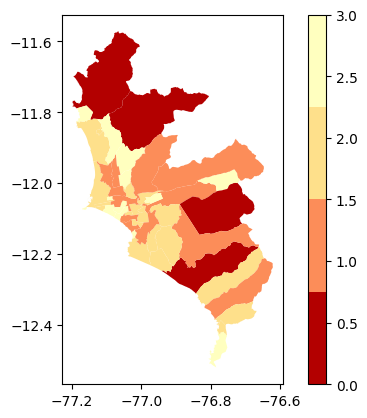

In [196]:
result_df.plot(column="score", cmap=score_cmap, vmin=0, vmax=3, legend=True)